<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-8/blob/main/Ejercicio1_clustering_jerarquico_20newsgroups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering jerarquico sobre el dataset 20 Newsgroups

**Objetivo:** encontrar grupos de documentos en el dataset *20 Newsgroups* de scikit-learn mediante **clustering jerarquico aglomerativo**, probar cuatro criterios de enlace (*linkage*): `ward`, `complete`, `average` y `single`, determinar cual tuvo mas exito y explicar los hallazgos.

**Enfoque:**
- Las etiquetas de categoria (el grupo de noticias de cada mensaje) **no se usan para agrupar**; solo se emplean despues para validar los grupos hallados.
- Cada documento se representa con **TF-IDF** y luego se reduce con **LSA** (`TruncatedSVD`) a 100 dimensiones, normalizando cada vector a longitud 1. Con vectores normalizados, la distancia euclidiana equivale a la distancia coseno (ordenan los pares de la misma forma), y esto permite usar `ward`, que exige distancia euclidiana.
- Para que el arbol sea manejable, se trabaja con una muestra de hasta 250 documentos por categoria.

Contenido:
1. Criterios de enlace
2. Carga y preparacion de los datos
3. Construccion de las jerarquias y dendrogramas
4. Corte del arbol y comparacion de criterios
5. Robustez del resultado con distintas muestras
6. Cuantos grupos elegir
7. Hallazgos del mejor criterio
8. Interpretacion y conclusiones

**Nota:** la primera ejecucion descarga el dataset (unos 14 MB), por lo que requiere conexion a internet, algo que Colab ya tiene.

## 1. Criterios de enlace

En el clustering aglomerativo cada documento empieza como su propio grupo, y en cada paso se fusionan los dos grupos mas cercanos. El criterio de enlace define **como se mide la distancia entre dos grupos**:

| Criterio | Distancia entre dos grupos | Comportamiento esperado |
|---|---|---|
| `ward` | Aumento de la varianza interna al fusionarlos (minimiza la varianza dentro de los grupos) | Grupos compactos y de tamano parecido |
| `complete` | Distancia **maxima** entre un par de puntos, uno de cada grupo | Grupos compactos; sensible a valores atipicos |
| `average` | Distancia **promedio** entre todos los pares de puntos | Punto intermedio entre `complete` y `single` |
| `single` | Distancia **minima** entre un par de puntos, uno de cada grupo | Tiende al "efecto cadena": un grupo enorme que absorbe puntos uno a uno y muchos grupos diminutos |

Como se vio en clase, distintos metodos de vinculacion producen distintos agrupamientos jerarquicos.

## 0. Librerias

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import Normalizer
from sklearn import metrics

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 110

## 2. Carga y preparacion de los datos

### 2.1 Parametros del experimento

Se eligen 5 categorias tematicamente distintas. Puedes modificar `CATEGORIAS` (por ejemplo, incluir categorias muy parecidas entre si) y volver a ejecutar todo el notebook.

Se eliminan encabezados, firmas y citas de los mensajes (`remove=("headers", "footers", "quotes")`), porque contienen pistas que delatan la categoria (nombres de servidores, listas de correo, etc.) y harian el problema artificialmente facil.

In [2]:
CATEGORIAS = [
    "comp.graphics",
    "rec.sport.hockey",
    "sci.space",
    "talk.politics.guns",
    "sci.med",
]
MAX_DOCS_POR_CATEGORIA = 250
N_COMPONENTES_LSA = 100
METODOS = ["ward", "complete", "average", "single"]

bunch = fetch_20newsgroups(
    subset="all",
    categories=CATEGORIAS,
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=RANDOM_STATE,
)

nombres_categorias = list(bunch.target_names)
K = len(nombres_categorias)

conteo = pd.Series(bunch.target).map(dict(enumerate(nombres_categorias))).value_counts()
print("Documentos disponibles por categoria:")
display(conteo.to_frame("documentos"))

Documentos disponibles por categoria:


,documentos
rec.sport.hockey,999
sci.med,990
sci.space,987
comp.graphics,973
talk.politics.guns,910


### 2.2 Vectorizacion (TF-IDF) y reduccion (LSA)

1. `TfidfVectorizer` convierte cada texto en un vector de pesos por palabra. Se eliminan palabras vacias del ingles (`stop_words`), palabras que aparecen en mas de la mitad de los documentos (`max_df=0.5`) o en menos de 5 (`min_df=5`), y se usa `sublinear_tf` para amortiguar las palabras muy repetidas.
2. Se descartan los documentos que quedaron casi vacios (menos de 10 terminos distintos), porque no se pueden comparar de forma fiable.
3. `TruncatedSVD` (LSA) reduce a `N_COMPONENTES_LSA` dimensiones, y `Normalizer` deja cada vector con norma 1.

La funcion `preparar_datos` recibe una semilla, porque mas adelante se repite el experimento con varias muestras.

In [3]:
def preparar_datos(semilla):
    rng = np.random.RandomState(semilla)

    # Muestra balanceada: hasta MAX_DOCS_POR_CATEGORIA documentos por categoria
    indices = []
    for clase in range(K):
        candidatos = np.where(bunch.target == clase)[0]
        n = min(MAX_DOCS_POR_CATEGORIA, len(candidatos))
        indices.extend(rng.choice(candidatos, size=n, replace=False))
    indices = np.array(sorted(indices))

    textos = [bunch.data[i] for i in indices]
    y = bunch.target[indices]

    vectorizador = TfidfVectorizer(
        stop_words="english",
        max_df=0.5,
        min_df=5,
        sublinear_tf=True,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
    )
    X_tfidf = vectorizador.fit_transform(textos)

    # Descartar documentos casi vacios
    validos = np.asarray(X_tfidf.getnnz(axis=1) >= 10)
    X_tfidf = X_tfidf[validos]
    y = y[validos]

    svd = TruncatedSVD(n_components=N_COMPONENTES_LSA, random_state=semilla)
    X_lsa = Normalizer(copy=False).fit_transform(svd.fit_transform(X_tfidf))

    return {
        "X_tfidf": X_tfidf,
        "X_lsa": X_lsa,
        "y": y,
        "vectorizador": vectorizador,
        "var_explicada": svd.explained_variance_ratio_.sum(),
        "descartados": int((~validos).sum()),
    }


datos = preparar_datos(RANDOM_STATE)
X_tfidf = datos["X_tfidf"]
X_lsa = datos["X_lsa"]
y = datos["y"]
vectorizador = datos["vectorizador"]

print("Documentos usados:", X_lsa.shape[0], "| descartados por vacios:", datos["descartados"])
print("Matriz TF-IDF:", X_tfidf.shape, "| Matriz LSA:", X_lsa.shape)
print(f"Varianza explicada por LSA: {datos['var_explicada']:.1%}")
print("Documentos por categoria:", dict(zip(nombres_categorias, np.bincount(y))))

Documentos usados: 1046 | descartados por vacios: 204
Matriz TF-IDF: (1046, 3353) | Matriz LSA: (1046, 100)
Varianza explicada por LSA: 27.7%
Documentos por categoria: {'comp.graphics': np.int64(211), 'rec.sport.hockey': np.int64(205), 'sci.med': np.int64(216), 'sci.space': np.int64(206), 'talk.politics.guns': np.int64(208)}


## 3. Construccion de las jerarquias y dendrogramas

Con `linkage` se construye la jerarquia completa (la secuencia de todas las fusiones) para cada criterio. Ademas se calcula el **coeficiente de correlacion cofenetico**: mide que tan fielmente las distancias del dendrograma reproducen las distancias originales entre documentos (mas cercano a 1 es mejor).

In [4]:
distancias_originales = pdist(X_lsa, metric="euclidean")

enlaces = {}
cofenetica = {}
for metodo in METODOS:
    Z = linkage(X_lsa, method=metodo, metric="euclidean")
    enlaces[metodo] = Z
    cofenetica[metodo] = cophenet(Z, distancias_originales)[0]

print("Correlacion cofenetica por criterio:")
display(pd.Series(cofenetica, name="cofenetica").round(4).to_frame())

Correlacion cofenetica por criterio:


,cofenetica
ward,0.2774
complete,0.3570
average,0.5307
single,0.2355


### 3.1 Dendrogramas

Se muestran truncados a las ultimas 30 fusiones (cada hoja representa un grupo de documentos, con el numero de documentos entre parentesis). La linea roja marca la altura de corte que deja exactamente `K` grupos, donde `K` es el numero de categorias reales; las ramas por debajo del corte se colorean por grupo.

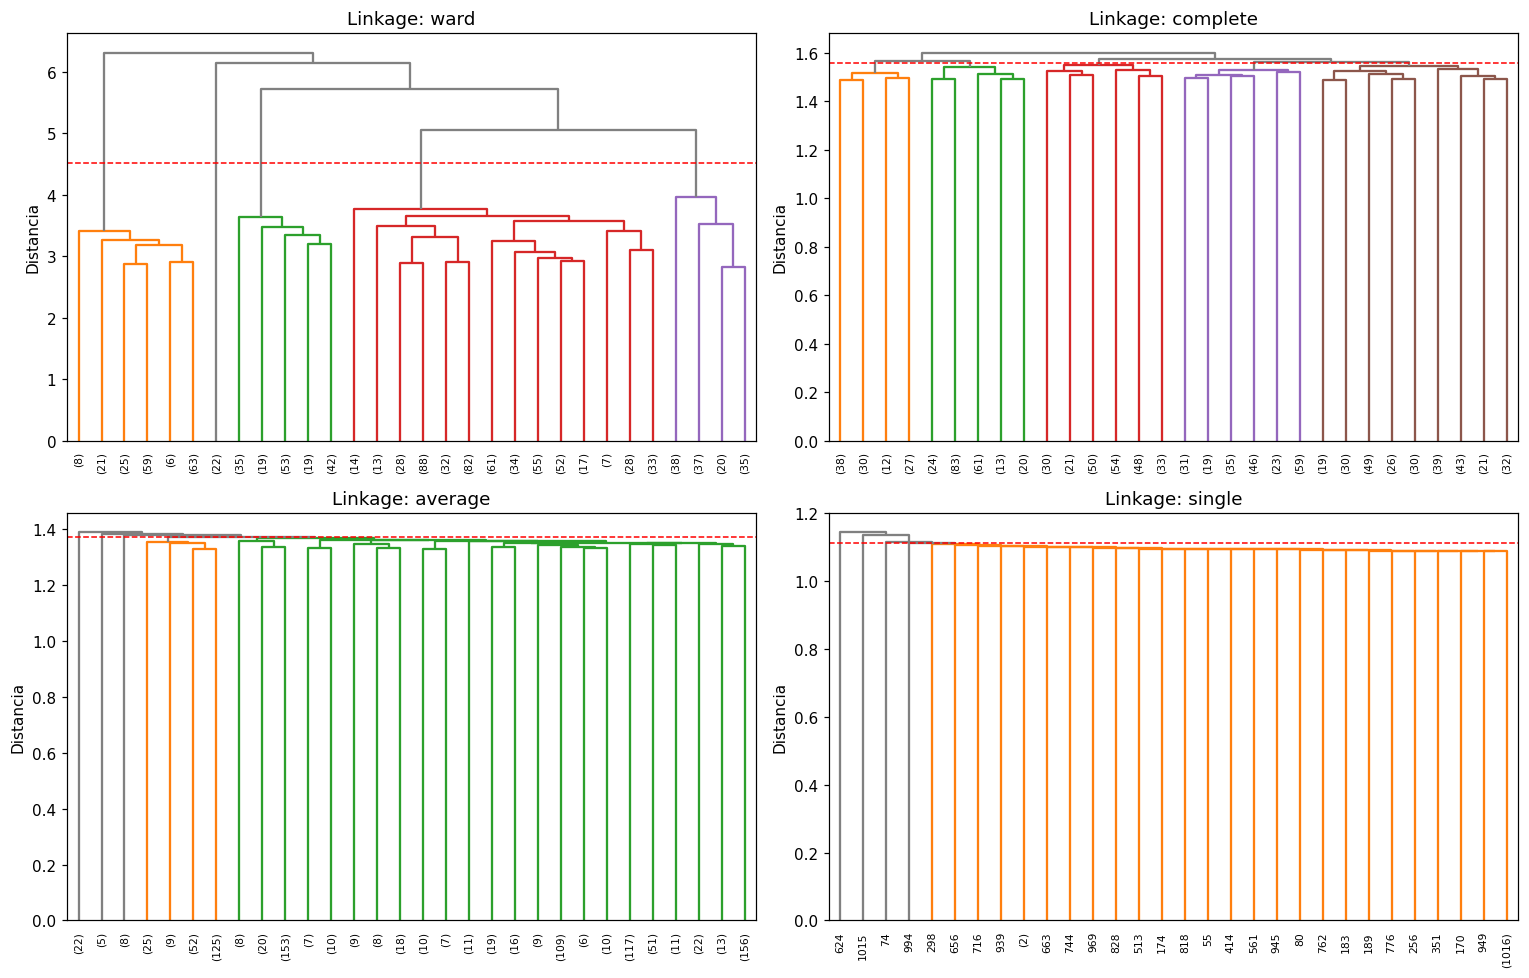

In [5]:
def altura_de_corte(Z, k):
    # Altura intermedia entre la ultima fusion conservada y la primera deshecha para obtener k grupos
    n = Z.shape[0] + 1
    return (Z[n - k - 1, 2] + Z[n - k, 2]) / 2


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metodo in zip(axes.ravel(), METODOS):
    Z = enlaces[metodo]
    corte = altura_de_corte(Z, K)
    dendrogram(
        Z,
        ax=ax,
        truncate_mode="lastp",
        p=30,
        show_leaf_counts=True,
        leaf_rotation=90,
        leaf_font_size=7,
        color_threshold=corte,
        above_threshold_color="gray",
    )
    ax.axhline(corte, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Linkage: {metodo}")
    ax.set_ylabel("Distancia")
plt.tight_layout()
plt.show()

## 4. Corte del arbol y comparacion de criterios

Se corta cada jerarquia para obtener `K` grupos con `fcluster(..., criterion="maxclust")` y se evalua el resultado con:

**Validacion externa** (compara contra las categorias reales):
- **ARI** (Adjusted Rand Index): 1 es coincidencia perfecta, 0 equivale al azar.
- **NMI**, **Homogeneidad**, **Completitud** y **V-measure**: entre 0 y 1, mayor es mejor. La homogeneidad mide si cada grupo contiene documentos de una sola categoria; la completitud, si cada categoria queda dentro de un solo grupo.
- **Pureza**: fraccion de documentos que pertenece a la categoria mayoritaria de su grupo.

**Validacion interna** (solo usa los datos y los grupos): **Silueta** (mayor es mejor), **Calinski-Harabasz** (mayor es mejor) y **Davies-Bouldin** (menor es mejor).

Se agregan dos indicadores de estructura: el **porcentaje de documentos en el grupo mas grande** (un valor muy alto revela efecto cadena) y el **coeficiente cofenetico**.

In [6]:
def pureza(y_real, etiquetas):
    tabla = pd.crosstab(etiquetas, y_real)
    return tabla.max(axis=1).sum() / tabla.values.sum()


def evaluar(metodo, Z, k):
    etiquetas = fcluster(Z, t=k, criterion="maxclust") - 1
    n_grupos = len(np.unique(etiquetas))

    fila = {
        "Criterio": metodo,
        "Grupos": n_grupos,
        "Grupo mayor (%)": 100 * np.bincount(etiquetas).max() / len(etiquetas),
        "Cofenetica": cofenetica[metodo],
        "ARI": metrics.adjusted_rand_score(y, etiquetas),
        "NMI": metrics.normalized_mutual_info_score(y, etiquetas),
        "Homogeneidad": metrics.homogeneity_score(y, etiquetas),
        "Completitud": metrics.completeness_score(y, etiquetas),
        "V-measure": metrics.v_measure_score(y, etiquetas),
        "Pureza": pureza(y, etiquetas),
    }
    if 2 <= n_grupos < len(etiquetas):
        fila["Silueta"] = metrics.silhouette_score(X_lsa, etiquetas)
        fila["Calinski-Harabasz"] = metrics.calinski_harabasz_score(X_lsa, etiquetas)
        fila["Davies-Bouldin"] = metrics.davies_bouldin_score(X_lsa, etiquetas)
    else:
        fila["Silueta"] = fila["Calinski-Harabasz"] = fila["Davies-Bouldin"] = np.nan
    return fila, etiquetas


filas = []
etiquetas_por_metodo = {}
for metodo in METODOS:
    fila, etiquetas = evaluar(metodo, enlaces[metodo], K)
    filas.append(fila)
    etiquetas_por_metodo[metodo] = etiquetas

tabla = pd.DataFrame(filas).set_index("Criterio")

print(f"Corte del arbol en K = {K} grupos")
display(tabla.round(3))

Corte del arbol en K = 5 grupos


,Grupos,Grupo mayor (%),Cofenetica,ARI,NMI,Homogeneidad,Completitud,V-measure,Pureza,Silueta,Calinski-Harabasz,Davies-Bouldin
Criterio,,,,,,,,,,,,
ward,5,52.008,0.277,0.306,0.479,0.430,0.541,0.479,0.608,0.035,19.670,4.596
complete,5,27.629,0.357,0.021,0.041,0.040,0.041,0.041,0.287,0.003,5.494,9.932
average,5,76.482,0.531,0.109,0.236,0.167,0.401,0.236,0.380,0.029,13.180,3.262
single,5,99.618,0.236,-0.000,0.007,0.004,0.202,0.007,0.208,-0.044,1.023,0.988


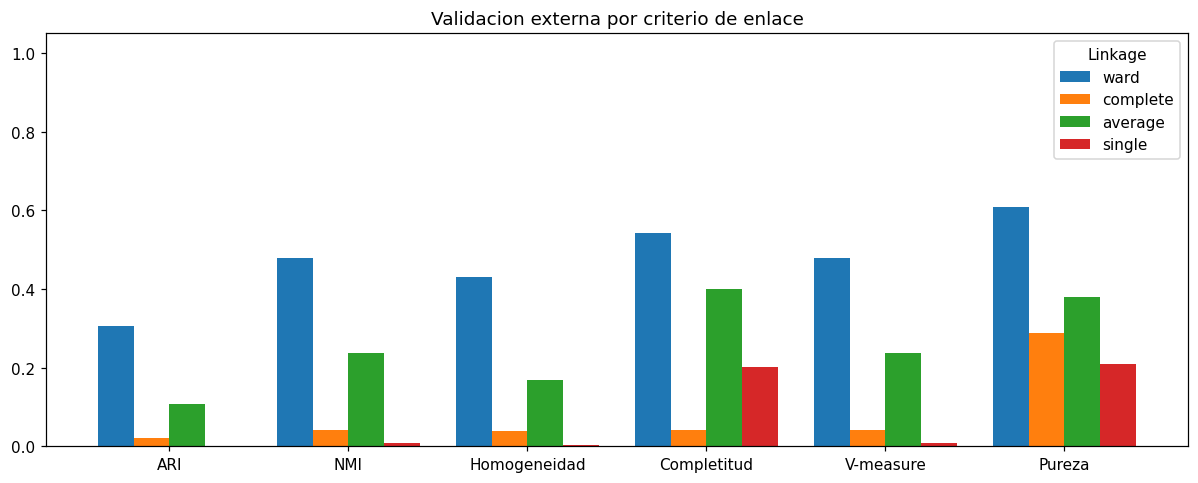

In [7]:
metricas_graf = ["ARI", "NMI", "Homogeneidad", "Completitud", "V-measure", "Pureza"]

fig, ax = plt.subplots(figsize=(11, 4.5))
ancho = 0.2
posiciones = np.arange(len(metricas_graf))
for i, metodo in enumerate(METODOS):
    valores = tabla.loc[metodo, metricas_graf].values.astype(float)
    ax.bar(posiciones + i * ancho, valores, width=ancho, label=metodo)
ax.set_xticks(posiciones + 1.5 * ancho)
ax.set_xticklabels(metricas_graf)
ax.set_ylim(0, 1.05)
ax.set_title("Validacion externa por criterio de enlace")
ax.legend(title="Linkage")
plt.tight_layout()
plt.show()

### 4.1 Tablas cruzadas: grupos hallados frente a categorias reales

Cada fila es un grupo hallado por el algoritmo y cada columna, una categoria real. En un agrupamiento ideal, cada fila tendria valores distintos de cero en una sola columna.

In [8]:
y_nombres = pd.Series(y).map(dict(enumerate(nombres_categorias))).values

for metodo in METODOS:
    print(f"Linkage: {metodo}")
    ct = pd.crosstab(pd.Series(etiquetas_por_metodo[metodo], name="grupo"),
                     pd.Series(y_nombres, name="categoria"))
    display(ct)

Linkage: ward


categoria,comp.graphics,rec.sport.hockey,sci.med,sci.space,talk.politics.guns
grupo,,,,,
0,0,179,2,1,0
1,0,0,22,0,0
2,132,2,13,19,2
3,78,24,177,181,84
4,1,0,2,5,122


Linkage: complete


categoria,comp.graphics,rec.sport.hockey,sci.med,sci.space,talk.politics.guns
grupo,,,,,
0,10,7,12,33,45
1,45,45,57,9,45
2,52,40,31,74,39
3,52,45,56,35,25
4,52,68,60,55,54


Linkage: average


categoria,comp.graphics,rec.sport.hockey,sci.med,sci.space,talk.politics.guns
grupo,,,,,
0,0,0,22,0,0
1,0,2,3,0,0
2,1,0,0,7,0
3,161,4,19,23,4
4,49,199,172,176,204


Linkage: single


categoria,comp.graphics,rec.sport.hockey,sci.med,sci.space,talk.politics.guns
grupo,,,,,
0,211,205,214,204,208
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,0,0,1,0


### 4.2 Ranking de criterios

Como se dispone de las categorias reales, la **validacion externa es la evidencia mas directa** de exito, por lo que el criterio principal es el **ARI**. Para confirmar que la conclusion no depende de una sola metrica, se calcula ademas un ranking promedio con ARI, V-measure, pureza y silueta (1 es el mejor puesto).

In [9]:
columnas_ranking = ["ARI", "V-measure", "Pureza", "Silueta"]
posiciones_ranking = tabla[columnas_ranking].rank(ascending=False, method="min")
posiciones_ranking["Puesto promedio"] = posiciones_ranking.mean(axis=1)

display(posiciones_ranking.sort_values("Puesto promedio"))

mejor_por_ari = tabla["ARI"].idxmax()
mejor_por_ranking = posiciones_ranking["Puesto promedio"].idxmin()
print("Mejor criterio segun ARI:", mejor_por_ari)
print("Mejor criterio segun el ranking promedio:", mejor_por_ranking)

,ARI,V-measure,Pureza,Silueta,Puesto promedio
Criterio,,,,,
ward,1.0,1.0,1.0,1.0,1.0
average,2.0,2.0,2.0,2.0,2.0
complete,3.0,3.0,3.0,3.0,3.0
single,4.0,4.0,4.0,4.0,4.0


Mejor criterio segun ARI: ward
Mejor criterio segun el ranking promedio: ward


## 5. Robustez del resultado con distintas muestras

Un solo experimento puede deberse a la suerte de la muestra. Se repite el procedimiento completo (muestreo, TF-IDF, LSA, jerarquia y corte en `K` grupos) con 5 semillas distintas y se resume el ARI de cada criterio.

ARI por semilla


,ward,complete,average,single
semilla 0,0.456,0.037,0.176,0.0
semilla 1,0.365,0.034,0.272,0.0
semilla 2,0.263,0.024,0.165,-0.0
semilla 3,0.353,0.036,0.002,0.0
semilla 4,0.326,0.064,0.155,0.0


Resumen


,ARI medio,Desv. estandar,ARI minimo,ARI maximo
ward,0.353,0.070,0.263,0.456
complete,0.039,0.015,0.024,0.064
average,0.154,0.097,0.002,0.272
single,0.000,0.000,-0.000,0.000


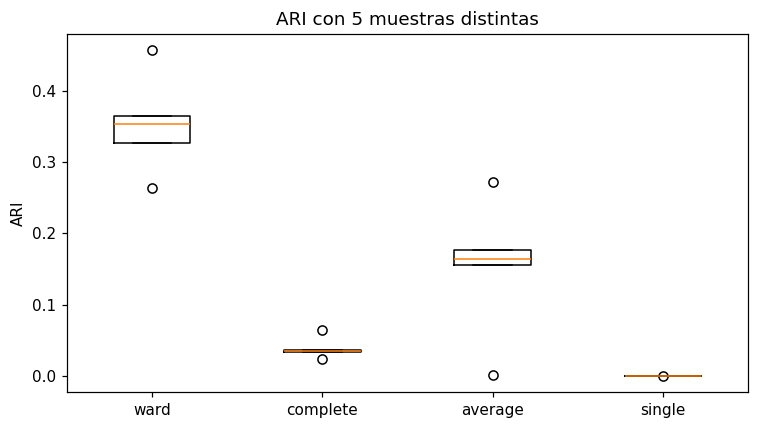

Mejor criterio segun el ARI medio: ward


In [10]:
SEMILLAS = [0, 1, 2, 3, 4]

ari_por_semilla = {metodo: [] for metodo in METODOS}
for semilla in SEMILLAS:
    d = preparar_datos(semilla)
    for metodo in METODOS:
        Z = linkage(d["X_lsa"], method=metodo, metric="euclidean")
        etiquetas = fcluster(Z, t=K, criterion="maxclust") - 1
        ari_por_semilla[metodo].append(metrics.adjusted_rand_score(d["y"], etiquetas))

tabla_ari = pd.DataFrame(ari_por_semilla, index=[f"semilla {s}" for s in SEMILLAS])
resumen_ari = pd.DataFrame({
    "ARI medio": tabla_ari.mean(),
    "Desv. estandar": tabla_ari.std(),
    "ARI minimo": tabla_ari.min(),
    "ARI maximo": tabla_ari.max(),
})

print("ARI por semilla")
display(tabla_ari.round(3))
print("Resumen")
display(resumen_ari.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([tabla_ari[m] for m in METODOS])
ax.set_xticklabels(METODOS)
ax.set_ylabel("ARI")
ax.set_title("ARI con 5 muestras distintas")
plt.tight_layout()
plt.show()

mejor_robusto = resumen_ari["ARI medio"].idxmax()
print("Mejor criterio segun el ARI medio:", mejor_robusto)

## 6. Cuantos grupos elegir

En un caso real no se conoce el numero de categorias. Para el mejor criterio se estudian dos senales:

1. **Saltos en las alturas de fusion:** un salto grande entre fusiones consecutivas indica que se estan uniendo grupos muy distintos, y que conviene cortar justo antes.
2. **Silueta y ARI segun `k`:** la silueta se puede calcular siempre; el ARI solo porque en este ejercicio si hay etiquetas reales.

Es importante recordar que estas senales son orientativas: en texto, los temas no siempre forman grupos bien separados.

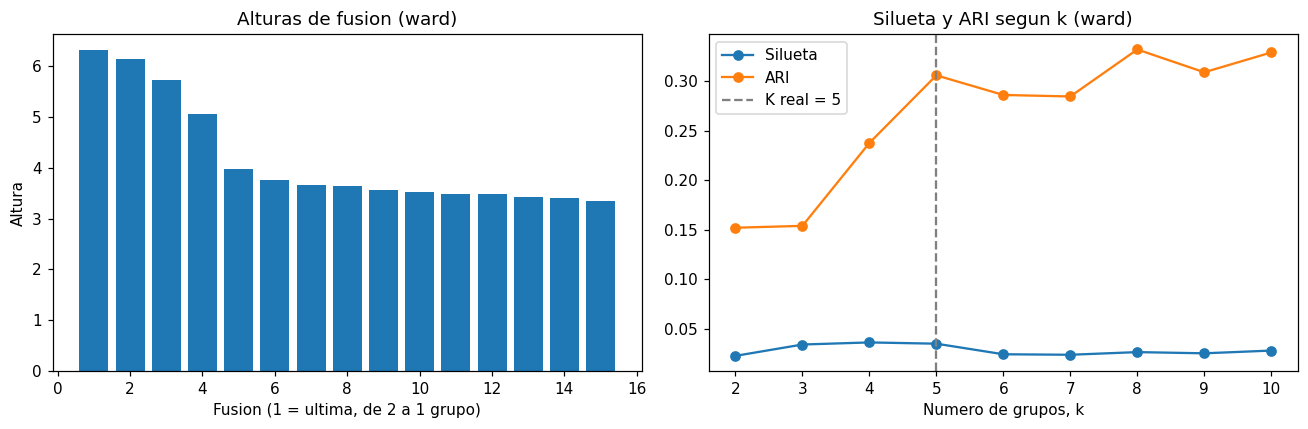

Mayor salto de altura sugiere k = 5 (numero real de categorias: 5)
Silueta maxima en k = 4


In [11]:
mejor = mejor_por_ari
Z_mejor = enlaces[mejor]

# Alturas de las ultimas 15 fusiones, de la ultima (2 -> 1 grupo) hacia atras
alturas = Z_mejor[-15:, 2][::-1]
saltos = alturas[:-1] - alturas[1:]
k_sugerido = int(np.argmax(saltos)) + 2

ks = range(2, 11)
sil_k, ari_k = [], []
for k in ks:
    et = fcluster(Z_mejor, t=k, criterion="maxclust") - 1
    sil_k.append(metrics.silhouette_score(X_lsa, et) if len(np.unique(et)) >= 2 else np.nan)
    ari_k.append(metrics.adjusted_rand_score(y, et))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(alturas) + 1), alturas, color="tab:blue")
axes[0].set_xlabel("Fusion (1 = ultima, de 2 a 1 grupo)")
axes[0].set_ylabel("Altura")
axes[0].set_title(f"Alturas de fusion ({mejor})")

axes[1].plot(list(ks), sil_k, marker="o", label="Silueta")
axes[1].plot(list(ks), ari_k, marker="o", label="ARI")
axes[1].axvline(K, color="gray", linestyle="--", label=f"K real = {K}")
axes[1].set_xlabel("Numero de grupos, k")
axes[1].set_title(f"Silueta y ARI segun k ({mejor})")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mayor salto de altura sugiere k = {k_sugerido} (numero real de categorias: {K})")
print(f"Silueta maxima en k = {list(ks)[int(np.nanargmax(sil_k))]}")

## 7. Hallazgos del mejor criterio

Se analiza el agrupamiento del criterio con mayor ARI: composicion de cada grupo, terminos mas representativos y una proyeccion en 2D. Los terminos de cada grupo se obtienen promediando los vectores TF-IDF de sus documentos y tomando las palabras con mayor peso.

Composicion de cada grupo (% por categoria), linkage = ward


categoria,comp.graphics,rec.sport.hockey,sci.med,sci.space,talk.politics.guns
grupo,,,,,
0,0.0,98.4,1.1,0.5,0.0
1,0.0,0.0,100.0,0.0,0.0
2,78.6,1.2,7.7,11.3,1.2
3,14.3,4.4,32.5,33.3,15.4
4,0.8,0.0,1.5,3.8,93.8


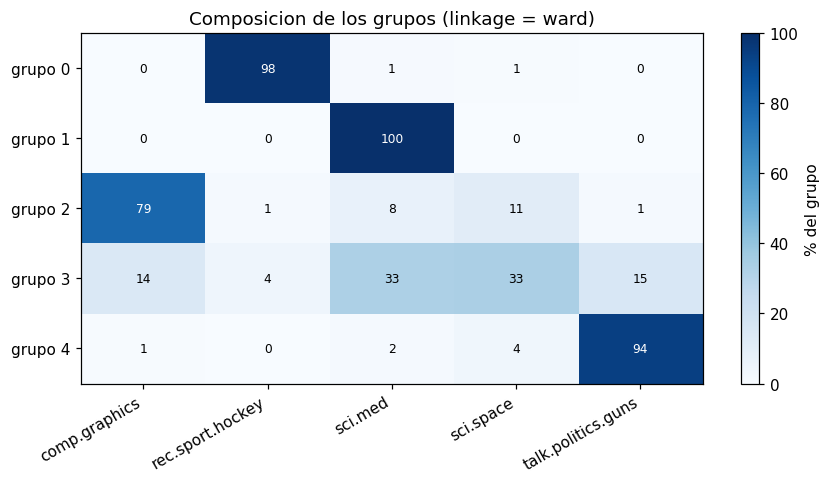

In [12]:
et_mejor = etiquetas_por_metodo[mejor]
terminos = np.array(vectorizador.get_feature_names_out())

ct_mejor = pd.crosstab(pd.Series(et_mejor, name="grupo"), pd.Series(y_nombres, name="categoria"))
porcentaje_fila = ct_mejor.div(ct_mejor.sum(axis=1), axis=0) * 100

print(f"Composicion de cada grupo (% por categoria), linkage = {mejor}")
display(porcentaje_fila.round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(porcentaje_fila.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(porcentaje_fila.columns)))
ax.set_xticklabels(porcentaje_fila.columns, rotation=30, ha="right")
ax.set_yticks(range(len(porcentaje_fila.index)))
ax.set_yticklabels([f"grupo {g}" for g in porcentaje_fila.index])
for i in range(porcentaje_fila.shape[0]):
    for j in range(porcentaje_fila.shape[1]):
        valor = porcentaje_fila.values[i, j]
        ax.text(j, i, f"{valor:.0f}", ha="center", va="center",
                color="white" if valor > 55 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="% del grupo")
ax.set_title(f"Composicion de los grupos (linkage = {mejor})")
plt.tight_layout()
plt.show()

In [13]:
print(f"TERMINOS MAS REPRESENTATIVOS POR GRUPO (linkage = {mejor})")
print()
for grupo in np.unique(et_mejor):
    miembros = np.where(et_mejor == grupo)[0]
    centroide = np.asarray(X_tfidf[miembros].mean(axis=0)).ravel()
    top = terminos[np.argsort(centroide)[::-1][:10]]

    fila = ct_mejor.loc[grupo]
    categoria_dominante = fila.idxmax()
    pureza_grupo = fila.max() / fila.sum()

    print(f"Grupo {grupo}: {len(miembros)} documentos | categoria dominante: "
          f"{categoria_dominante} ({pureza_grupo:.0%})")
    print("   terminos:", ", ".join(top))

TERMINOS MAS REPRESENTATIVOS POR GRUPO (linkage = ward)

Grupo 0: 182 documentos | categoria dominante: rec.sport.hockey (98%)
   terminos: game, hockey, team, games, play, year, season, think, players, just
Grupo 1: 22 documentos | categoria dominante: sci.med (100%)
   terminos: chastity, dsl, shameful, cadre, intellect, geb, skepticism, banks, surrender, pitt
Grupo 2: 168 documentos | categoria dominante: comp.graphics (79%)
   terminos: thanks, know, files, image, format, software, program, does, file, advance
Grupo 3: 544 documentos | categoria dominante: sci.space (33%)
   terminos: like, just, people, know, think, don, space, time, ve, good
Grupo 4: 130 documentos | categoria dominante: talk.politics.guns (94%)
   terminos: weapons, gun, fbi, people, don, law, guns, batf, children, government


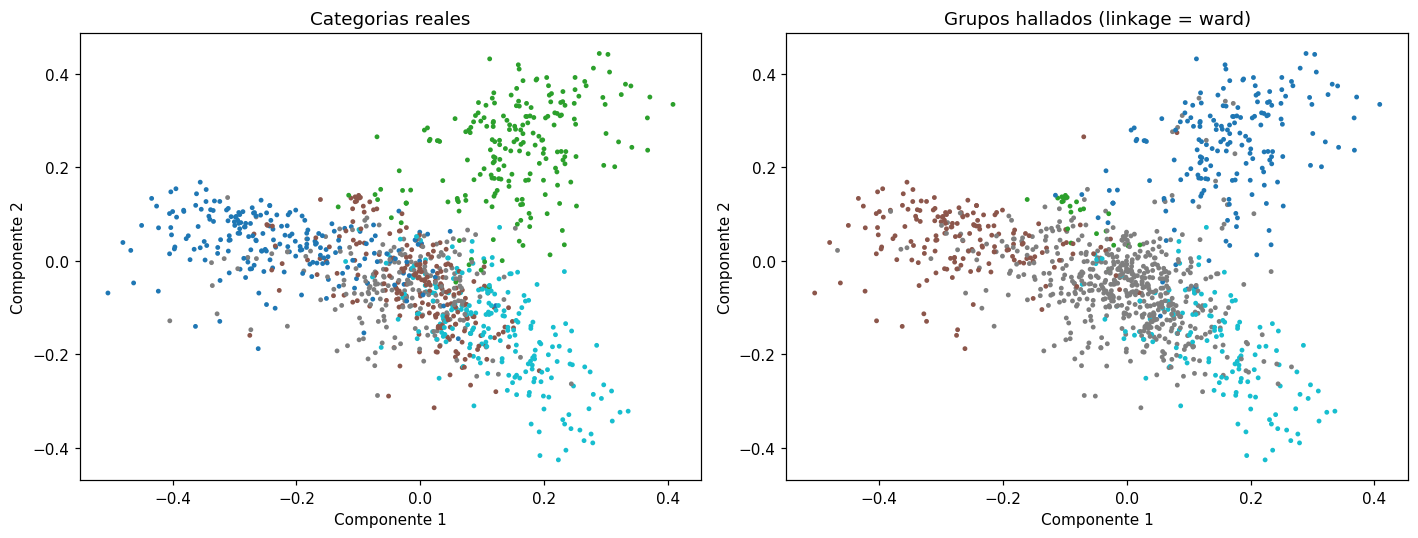

In [14]:
proyeccion = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_lsa)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, etiquetas, titulo in [
    (axes[0], y, "Categorias reales"),
    (axes[1], et_mejor, f"Grupos hallados (linkage = {mejor})"),
]:
    dispersion = ax.scatter(proyeccion[:, 0], proyeccion[:, 1], c=etiquetas,
                            cmap="tab10", s=10, edgecolor="none")
    ax.set_title(titulo)
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")

plt.tight_layout()
plt.show()

In [15]:
print("RESUMEN AUTOMATICO DE HALLAZGOS")
print("=" * 60)
print(f"Documentos analizados: {len(y)} | categorias reales: {K} | criterios probados: {', '.join(METODOS)}")
print()

print("Resultado por criterio (corte en K grupos):")
for metodo in METODOS:
    f = tabla.loc[metodo]
    print(f"  {metodo:<9} ARI={f['ARI']:.3f}  V-measure={f['V-measure']:.3f}  "
          f"Pureza={f['Pureza']:.3f}  Grupo mayor={f['Grupo mayor (%)']:.1f}%")
print()

peor = tabla["ARI"].idxmin()
print(f"Criterio con mejor ARI: {mejor} ({tabla.loc[mejor, 'ARI']:.3f})")
print(f"Criterio con peor ARI: {peor} ({tabla.loc[peor, 'ARI']:.3f})")
print(f"Mejor criterio por ARI medio en {len(SEMILLAS)} muestras: {mejor_robusto} "
      f"({resumen_ari.loc[mejor_robusto, 'ARI medio']:.3f})")
print()

encadenamiento = tabla["Grupo mayor (%)"].idxmax()
print(f"Criterio con el grupo mas grande: {encadenamiento} "
      f"({tabla.loc[encadenamiento, 'Grupo mayor (%)']:.1f}% de los documentos en un solo grupo)")
print()

print(f"Como se reparte cada categoria entre los grupos de '{mejor}':")
for categoria in ct_mejor.columns:
    columna = ct_mejor[categoria]
    grupo_principal = columna.idxmax()
    print(f"  {categoria:<20} {columna.max() / columna.sum():.0%} de sus documentos "
          f"quedan en el grupo {grupo_principal}")

RESUMEN AUTOMATICO DE HALLAZGOS
Documentos analizados: 1046 | categorias reales: 5 | criterios probados: ward, complete, average, single

Resultado por criterio (corte en K grupos):
  ward      ARI=0.306  V-measure=0.479  Pureza=0.608  Grupo mayor=52.0%
  complete  ARI=0.021  V-measure=0.041  Pureza=0.287  Grupo mayor=27.6%
  average   ARI=0.109  V-measure=0.236  Pureza=0.380  Grupo mayor=76.5%
  single    ARI=-0.000  V-measure=0.007  Pureza=0.208  Grupo mayor=99.6%

Criterio con mejor ARI: ward (0.306)
Criterio con peor ARI: single (-0.000)
Mejor criterio por ARI medio en 5 muestras: ward (0.353)

Criterio con el grupo mas grande: single (99.6% de los documentos en un solo grupo)

Como se reparte cada categoria entre los grupos de 'ward':
  comp.graphics        63% de sus documentos quedan en el grupo 2
  rec.sport.hockey     87% de sus documentos quedan en el grupo 0
  sci.med              82% de sus documentos quedan en el grupo 3
  sci.space            88% de sus documentos quedan 

## 8. Interpretacion y conclusiones

Los valores exactos dependen de la muestra y de las categorias elegidas, por lo que esta seccion explica **como leer los resultados** de las celdas anteriores. La celda de *resumen automatico* (seccion 7) imprime las cifras concretas de tu ejecucion.

### 8.1 Como determinar el criterio de enlace con mas exito

Un criterio tuvo mas exito si:
1. Obtiene el mayor **ARI** (y de forma consistente, con un **ARI medio** alto y baja desviacion en la seccion 5), lo que confirma que la ventaja no se debe a la muestra.
2. Su **V-measure** y su **pureza** acompanan al ARI (las metricas externas deberian ser coherentes entre si).
3. No produce un agrupamiento degenerado: el porcentaje de documentos en el **grupo mayor** no debe ser desproporcionado.

La silueta y el coeficiente cofenetico son evidencia de apoyo. La silueta favorece grupos compactos y esfericos, y en texto (espacio de alta dimension) suele tener valores bajos incluso cuando el agrupamiento es bueno; por eso no debe usarse sola para decidir.

### 8.2 Que esperar de cada criterio (comportamiento tipico)

- **`single`:** por su definicion (distancia minima), un documento puede ser absorbido por un grupo si esta cerca de uno solo de sus miembros. En datos de texto, donde hay muchos documentos "puente" con vocabulario generico, suele dar un grupo gigante y varios grupos de uno o dos documentos (efecto cadena). Si en tu ejecucion el porcentaje del grupo mayor es cercano al 100% y el ARI cercano a 0, este es el motivo.
- **`ward`:** al minimizar el aumento de varianza en cada fusion, tiende a producir grupos compactos y de tamano parecido, lo que encaja bien con conjuntos de categorias balanceadas como esta muestra.
- **`complete` y `average`:** son intermedios. `complete` es sensible a valores atipicos, porque una sola pareja de documentos lejanos aumenta la distancia entre dos grupos; `average` amortigua ese efecto usando todos los pares.

Compara estas expectativas con tus tablas: si el resultado difiere, la explicacion suele estar en la geometria de los datos y no en un error.

### 8.3 Como explicar los hallazgos del clustering

Para cada grupo, la seccion 7 entrega tres elementos que permiten describir que encontro el algoritmo:
1. **Composicion:** la categoria dominante y su porcentaje (pureza del grupo). Un grupo con 90% de una categoria es un tema bien identificado.
2. **Terminos representativos:** las palabras con mayor peso TF-IDF medio confirman el tema (por ejemplo, vocabulario de hockey, espacio, armas, medicina o graficos por computador). Si los terminos son coherentes pero la composicion es mixta, el algoritmo encontro un subtema que cruza categorias.
3. **Categorias divididas o mezcladas:** en la tabla de composicion, una categoria repartida entre varios grupos indica subtemas internos; dos categorias juntas en un mismo grupo indican vocabulario compartido (por ejemplo, temas cientificos o tecnicos cercanos). Esto se refleja en la homogeneidad (grupos mezclados) y en la completitud (categorias partidas).

### 8.4 Limitaciones

- La representacion TF-IDF + LSA captura vocabulario, no significado; mensajes cortos, con poco texto o fuera de tema son dificiles de agrupar.
- El clustering jerarquico requiere calcular distancias entre todos los pares de documentos (coste cuadratico en memoria y tiempo), por lo que se trabajo con una muestra; para corpus grandes se prefieren metodos como K-means o se agrupa sobre representaciones reducidas.
- Las etiquetas del dataset son las categorias de los foros, que no siempre coinciden con los temas reales de cada mensaje: un ARI moderado no implica necesariamente un mal agrupamiento.
- Los resultados dependen de las categorias elegidas y de los parametros de vectorizacion (`min_df`, `max_df`, `N_COMPONENTES_LSA`); conviene probar variantes.

**Experimentos sugeridos:** cambiar `CATEGORIAS` por temas parecidos entre si (por ejemplo, dos grupos de politica o de computacion), variar `N_COMPONENTES_LSA` (50, 200) y comparar la estabilidad de cada criterio.